# LING 498 Hackathon — Prompt 10

## Onset clusters (phonotactics proxy)

**Category:** Phonology

**Question:** Are onset clusters Zipf-like? Do rare clusters align with markedness/phonotactic restrictions?

- **Data:** CMUdict pronunciations (strip stress digits).
- **Items to Count:** Phones from start up to first vowel; join with "-" (e.g., S-T-R).

**Steps**
- Define vowel set (provided in notebook scaffold).
- For each pronunciation, collect initial phones until first vowel.
- Join as a cluster type; count clusters; run Zipf report/plot.
- Interpret: common vs rare clusters; lexicalization vs phonotactic constraints.

**Deliverable:** Top-15 onsets + 2 notes on markedness + 1 limitation of the vowel-set heuristic.

In [1]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

In [2]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Cluster Types: {len(ranked)} | Clusters: {sum(c for _,c in ranked)}")
    print("Top clusters:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Regular-scale plot
def zipf_plot(ranked, n=30, title="Frequency by Rank"):
    import matplotlib.pyplot as plt
    number_to_plot = min(n, len(ranked))
    ranks = list(range(1, number_to_plot + 1))
    frequencies = []
    for i in ranks:
        frequencies.append(ranked[i - 1][1])
    plt.figure(figsize=(8, 5))
    plt.plot(ranks, frequencies, marker="o")
    plt.xlabel("Rank (1 = most frequent)")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
# load the phonetic dictionary (scaffold)
cmu_dict = cmudict.dict()

In [4]:
# inspect data
print("Number of word entries:", len(cmu_dict))
print()

sample_words = list(cmu_dict.keys())[:10]

for word in sample_words:
    pronunciations = cmu_dict[word]
    print(word, "→", pronunciations)

Number of word entries: 123455

a → [['AH0'], ['EY1']]
a. → [['EY1']]
a42128 → [['EY1', 'F', 'AO1', 'R', 'T', 'UW1', 'W', 'AH1', 'N', 'T', 'UW1', 'EY1', 'T']]
aaa → [['T', 'R', 'IH2', 'P', 'AH0', 'L', 'EY1']]
aaberg → [['AA1', 'B', 'ER0', 'G']]
aachen → [['AA1', 'K', 'AH0', 'N']]
aachener → [['AA1', 'K', 'AH0', 'N', 'ER0']]
aaker → [['AA1', 'K', 'ER0']]
aalseth → [['AA1', 'L', 'S', 'EH0', 'TH']]
aamodt → [['AA1', 'M', 'AH0', 'T']]


In [5]:
# define vowels
vowels = [
    "AA", "AE", "AH", "AO", "AW", "AY",
    "EH", "ER", "EY",
    "IH", "IY",
    "OW", "OY",
    "UH", "UW"
]

In [6]:
# strip stress digits
def strip_stress(phone):
    phone_without_stress = re.sub(r"\d", "", phone)
    return phone_without_stress

# testing function
print(strip_stress("AE1"))
print(strip_stress("AH0"))
print(strip_stress("IY2"))
print(strip_stress("K"))

AE
AH
IY
K


In [7]:
# extract onset cluster
def get_onset_cluster(phones):
    onset_phones = []
    for phone in phones:
        clean_phone = strip_stress(phone)
        if clean_phone in vowels:
            break
        onset_phones.append(clean_phone)
    cluster_type = "-".join(onset_phones)
    return cluster_type

In [8]:
test_onsets = [
    ["P", "L", "EY1"],
    ["S", "T", "R", "IY1", "T"],
    ["K", "AE1", "T"],
    ["AE1", "P", "AH0", "L"]
]

for phones in test_onsets:
    cluster_type = get_onset_cluster(phones)
    print(phones, "→", cluster_type)
    
# if there are no onset clusters = "" or empty

['P', 'L', 'EY1'] → P-L
['S', 'T', 'R', 'IY1', 'T'] → S-T-R
['K', 'AE1', 'T'] → K
['AE1', 'P', 'AH0', 'L'] → 


In [9]:
cluster_types = []

for word in cmu_dict:
    pronunciations = cmu_dict[word]

    for phones in pronunciations:
        cluster_type = get_onset_cluster(phones)

        # Exclude vowel-initial words with no onset cluster
        if cluster_type != "":
            cluster_types.append(cluster_type)

In [10]:
print("Number of Cluster Type tokens:", len(cluster_types))
print("First 30 Cluster Type tokens:")
print(cluster_types[:20])

Number of Cluster Type tokens: 113614
First 30 Cluster Type tokens:
['T-R', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']



=== CMUdict Onset Clusters ===
Cluster Types: 154 | Clusters: 113614
Top clusters:
 1. K                                        9837
 2. M                                        9294
 3. R                                        7467
 4. B                                        7177
 5. D                                        7173
 6. S                                        6919
 7. HH                                       6134
 8. L                                        5455
 9. P                                        5435
10. F                                        3923
11. W                                        3771
12. T                                        3524
13. N                                        3223
14. G                                        3173
15. V                                        2376

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.529
 f1/(3*f3) = 0.439
 f1/(4*f4) = 0.343
 f1/(5*f5) = 0.274


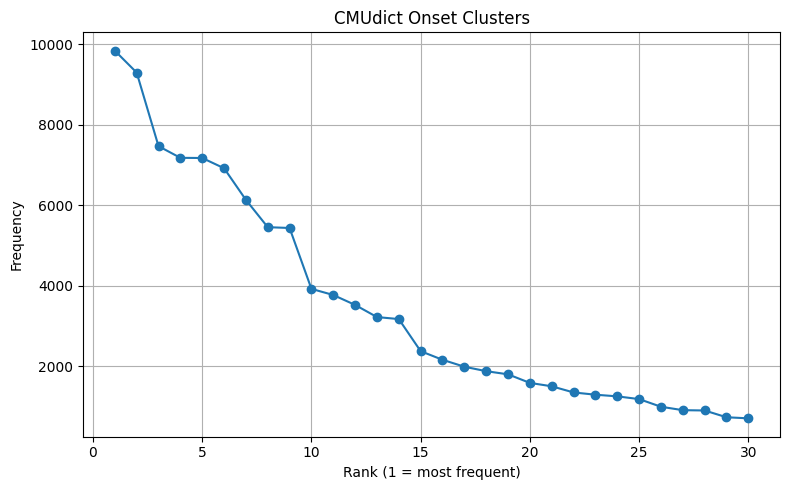

In [11]:
ranked = zipf_quick_report(cluster_types, title="CMUdict Onset Clusters")
zipf_plot(ranked, title="CMUdict Onset Clusters")

### Interpretation

The onset cluster distribution follows a Zipf-like pattern, with a small number of cluster types occurring much more frequently than the rest. Simple onsets such as `K`, `M`, `R`, and `B` are among the most common and occur in words such as *cat*, *man*, *red*, and *book*. In contrast, more complex clusters such as `S-T-R` (*street*) and `S-K-W` (*square*) appear much less often. Overall, the results show that English words are more likely to begin with simple onsets than with complex consonant clusters.

### Markedness

1. Simple onsets are considered less marked because they are easier to pronounce and are found in a larger number of English words. This helps explain why they appear more frequently in the corpus.

2. More complex onset clusters are more marked because English allows only certain consonant combinations at the beginning of words. For example, *street* (`S-T-R`) and *square* (`S-K-W`) are acceptable English clusters, but many other three-consonant combinations are not.

### Limitation of the Vowel-Set Heuristic

This method assumes that the onset ends at the first vowel phone in the CMUdict pronunciation. While this works well for most words, it depends entirely on the predefined vowel set and the dictionary pronunciations, so it may not always match how words are pronounced in natural speech or how other phonologists would analyze them.